In [1]:
!pip install torch torcheeg python-picard autoreject

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of mne to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mne[hdf5] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pymatreader to determine which version is compatible with other requirements. This 

In [2]:
import mne
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch 
import torcheeg
from torcheeg import datasets
from torcheeg import transforms
from torch.utils.data import Dataset

In [3]:
emotion_mapping = {
    (0, 0): "Boring",  # Low arousal, Low valence
    (0, 1): "Calm",    # Low arousal, High valence
    
    (1, 0): "Horror",  # High arousal, Low valence    
    (1, 1): "Funny"    # High arousal, High valence
}

In [4]:
def max_eeg_readings(df, max_readings):
    if isinstance(data, (pd.DataFrame, pd.Series)):
        arr = data.to_numpy()
    elif isinstance(data, np.ndarray):
        arr = data
    else:
        raise TypeError("Input must be a pandas DataFrame, Series, or numpy ndarray.")
    arr = arr[~np.isnan(arr)]
    arr = arr.reshape(-1)
    arr = np.sort(arr)
    arr = arr[::-1]
    return arr[:max_readings]

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_eeg_numpy(eeg_data, sfreq, ch_names=None, start=0, duration=10, title="EEG Channels"):
    """
    Plot EEG channels from a NumPy array.

    Parameters
    ----------
    eeg_data : np.ndarray
        2D array of shape (n_channels, n_samples)
    sfreq : float
        Sampling frequency in Hz
    ch_names : list of str
        Optional list of channel names
    start : float
        Start time (in seconds)
    duration : float
        Duration (in seconds)
    """
    n_channels, n_samples = eeg_data.shape
    start_idx = int(start * sfreq)
    end_idx = int((start + duration) * sfreq)
    time = np.arange(start_idx, end_idx) / sfreq

    plt.figure(figsize=(12, 8))
    offset = 0
    for i in range(n_channels):
        plt.plot(time, eeg_data[i, start_idx:end_idx] + offset, label=ch_names[i] if ch_names else f"Ch {i+1}")
        offset += np.ptp(eeg_data[i, start_idx:end_idx]) * 1.5  # spacing between channels

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV, relative offset)")
    plt.title(title)
    plt.legend(loc='upper right', fontsize='small')
    plt.tight_layout()
    plt.show()

In [6]:
def plot_sample(df, max_readings, duration, title):
    print(max_eeg_readings(df, max_readings))
    channels = list(df.columns)[:-1]
    plot_eeg_numpy(df[channels].to_numpy().T, 128, channels, 0, duration, title=title)   
    

In [7]:
def plot_all_subject_data(df_boring, df_calm, df_horror, df_funny, duration):
    max_readings = 12
    plot_sample(df_boring, max_readings, duration, "Boring Game Sample")
    plot_sample(df_calm, max_readings, duration, "Calm Game Sample")
    plot_sample(df_horror, max_readings, duration, "Horror Game Sample")
    plot_sample(df_funny, max_readings, duration, "Funny Game Sample")

In [8]:
def preprocessing_pieline(
    arr, epoch_length_in_secs,
    epoch_overlap_in_secs,
    band_pass_lower_bound_freq=1.0,
    band_pass_upper_bound_freq=40.0
):
    
    from mne.preprocessing import ICA
    from autoreject import AutoReject
    
    raw_filtered = arr.copy().filter(l_freq=band_pass_lower_bound_freq, h_freq=band_pass_upper_bound_freq)
    ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)
    ica.fit(raw_filtered)
    ica_data = ica.apply(arr)
    epochs = mne.make_fixed_length_epochs(
        ica_data, duration=epoch_length_in_secs, overlap=epoch_overlap_in_secs, preload=True
    )
    ar = AutoReject(random_state=42, n_jobs=-1)
    ar.fit(epochs)

    # Apply Autoreject cleaning
    epochs_clean = ar.transform(epochs)
    return epochs_clean, ica, ar


In [9]:
def preprocessing_pipeline(
    raw,
    epoch_length_in_secs,
    epoch_overlap_in_secs,
    band_pass_lower_bound_freq=1.0,
    band_pass_upper_bound_freq=40.0
):
    """
    EEG preprocessing pipeline using MNE and Autoreject.

    Steps:
        1. Band-pass filter (default 1–40 Hz)
        2. ICA using 'picard' for artifact removal
        3. Fixed-length epoching with overlap
        4. Autoreject for automatic epoch/channel cleaning

    Parameters
    ----------
    raw : mne.io.Raw
        Continuous EEG recording.
    epoch_length_in_secs : float
        Epoch duration in seconds.
    epoch_overlap_in_secs : float
        Overlap between consecutive epochs.
    band_pass_lower_bound_freq : float, optional
        Lower cutoff frequency for band-pass filter.
    band_pass_upper_bound_freq : float, optional
        Upper cutoff frequency for band-pass filter.

    Returns
    -------
    epochs_clean : mne.Epochs
        Cleaned, ready-to-use EEG epochs.
    ica : mne.preprocessing.ICA
        Fitted ICA object (for inspection or reuse).
    ar : autoreject.AutoReject
        Fitted AutoReject model.
    """
    import mne
    from mne.preprocessing import ICA
    from autoreject import AutoReject

    # Step 1: Band-pass filter
    raw_filtered = raw.copy().filter(
        l_freq=band_pass_lower_bound_freq,
        h_freq=band_pass_upper_bound_freq
    )

    # Step 2: ICA artifact correction
    ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)
    ica.fit(raw_filtered)
    raw_ica_clean = ica.apply(raw_filtered.copy())

    # Step 3: Epoching
    epochs = mne.make_fixed_length_epochs(
        raw_ica_clean,
        duration=epoch_length_in_secs,
        overlap=epoch_overlap_in_secs,
        preload=True
    )

    # Step 4: Autoreject cleaning
    ar = AutoReject(random_state=42, n_jobs=-1)
    ar.fit(epochs)
    epochs_clean = ar.transform(epochs)

    return epochs_clean, ica, ar


In [10]:
import mne
import numpy as np
import matplotlib.pyplot as plt

def plot_artifact_correlations(raw, channels, artifact_windows, baseline_window=(10, 15)):
    """
    Plot channel correlation matrices for artifact and baseline time windows.

    This function extracts EEG (or MEG) data from specified time windows, computes 
    channel-wise Pearson correlation matrices, and visualizes them as heatmaps.
    It can be used to compare suspected artifact periods with a clean baseline 
    segment to identify abnormal channel coupling patterns.

    Parameters
    ----------
    raw : mne.io.Raw
        The MNE Raw object containing the continuous EEG/MEG data.
    channels : list of str
        List of channel names corresponding to the data used for plotting.
        Typically `raw.ch_names` or a subset of it.
    artifact_windows : list of tuple
        List of time windows (start, stop) in seconds that mark suspected 
        artifact periods.
    baseline_window : tuple of float, optional
        A single time window (start, stop) in seconds representing a clean 
        baseline period for comparison. Default is (10, 15).

    Notes
    -----
    - The function assumes that data from all channels in `channels` are included
      in the Raw object and aligned in order.
    - Correlation matrices are plotted for each artifact window and one for the
      baseline window.
    """

    # Loop through each artifact window and compute correlation matrices
    for start, stop in artifact_windows:
        # Extract data and corresponding time points
        data, times = raw.get_data(start=start, stop=stop, return_times=True)

        # Compute Pearson correlation coefficients between channels
        corr_matrix = np.corrcoef(data)
        
        # --- Visualization ---
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
        ax.set_title(f'Channel correlation ({start:.1f}–{stop:.1f}s)')
        ax.set_xticks(range(len(channels)))
        ax.set_xticklabels(channels, rotation=90)
        ax.set_yticks(range(len(channels)))
        ax.set_yticklabels(channels)
        plt.colorbar(im, ax=ax, label='Correlation coefficient')
        plt.tight_layout()
        plt.show()

    # --- Baseline comparison ---
    # Extract baseline data and compute its correlation matrix
    data_base, _ = raw.get_data(start=baseline_window[0],
                                stop=baseline_window[1],
                                return_times=True)
    corr_baseline = np.corrcoef(data_base)

    # Plot baseline correlation matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(corr_baseline, vmin=-1, vmax=1, cmap='RdBu_r')
    plt.title(f'Baseline correlation ({baseline_window[0]}–{baseline_window[1]}s)')
    plt.xticks(range(len(channels)), channels, rotation=90)
    plt.yticks(range(len(channels)), channels)
    plt.colorbar(label='Correlation coefficient')
    plt.tight_layout()
    plt.show()

In [11]:
from sklearn.decomposition import FastICA

path = r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S01)/Preprocessed EEG Data/.csv format/S01G1AllChannels.csv'

df = pd.read_csv(path)

channels = list(df.columns)[:-1]

info = mne.create_info(ch_names=channels, sfreq=128, ch_types='eeg')
raw = mne.io.RawArray(df[channels].to_numpy().T, info)

In [12]:
from mne.time_frequency import Spectrum

spect = raw.compute_psd()
print(spect.shape)

raw_filtered = raw.copy()
raw_filtered.filter(l_freq=1.0, h_freq=None, fir_design='firwin')

spect_filtered = raw_filtered.compute_psd()
print(spect_filtered.shape)

(14, 1025)
(14, 1025)


In [13]:
from mne.preprocessing import ICA

ica = ICA(n_components=0.99, method='picard', max_iter=800, random_state=42)
ica.fit(raw_filtered)
raw_filtered_low = raw_filtered.copy().filter(l_freq=0.1, h_freq=40.)
ica_data = ica.apply(raw_filtered_low)

data_array, times_array = ica_data[:]
print(f"Shape of extracted data: {data_array.shape}")
print(f"Shape of extracted times: {times_array.shape}")

Shape of extracted data: (14, 38252)
Shape of extracted times: (38252,)


In [14]:
ica_psd = ica_data.compute_psd()

ica_tfr_multitaper = ica_data.compute_tfr('multitaper', [0.1, 40.])
ica_tfr_morlet = ica_data.compute_tfr('morlet', [0.1, 40.])


print(ica_psd.shape)
print(ica_tfr_multitaper.shape)
print(ica_tfr_morlet.shape)

(14, 1025)
(14, 2, 38252)
(14, 2, 38252)


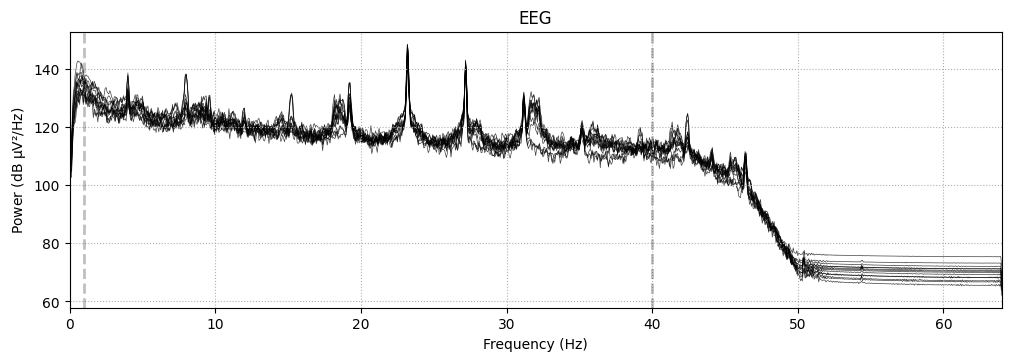

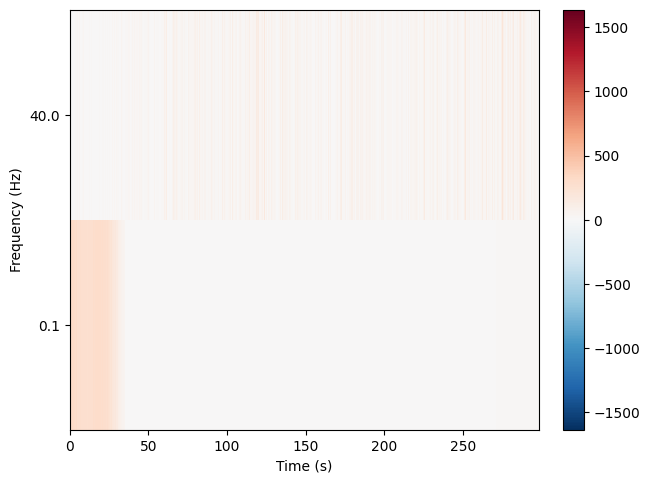

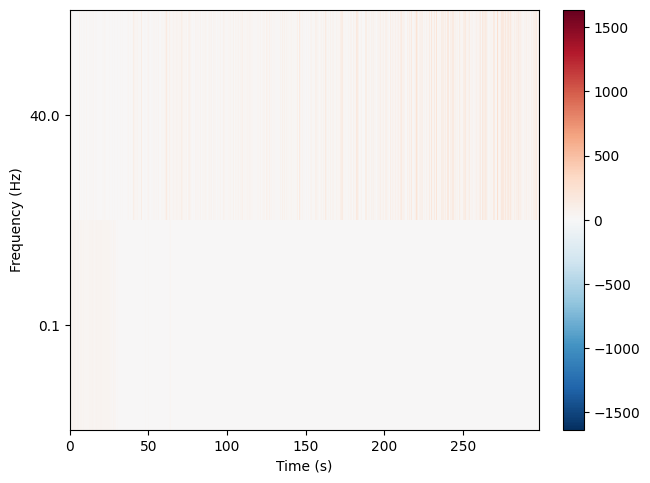

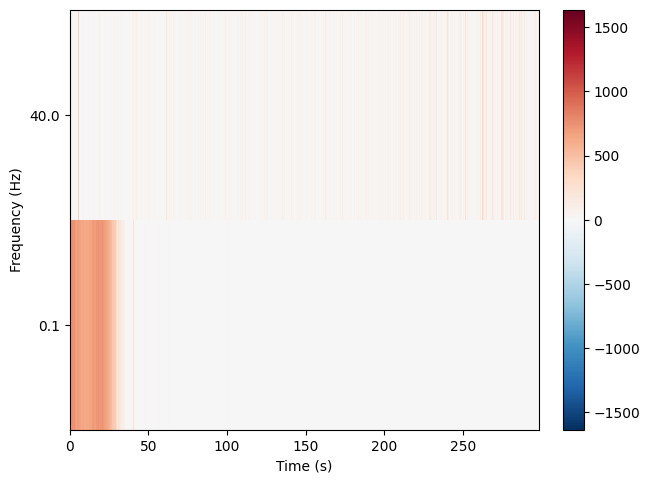

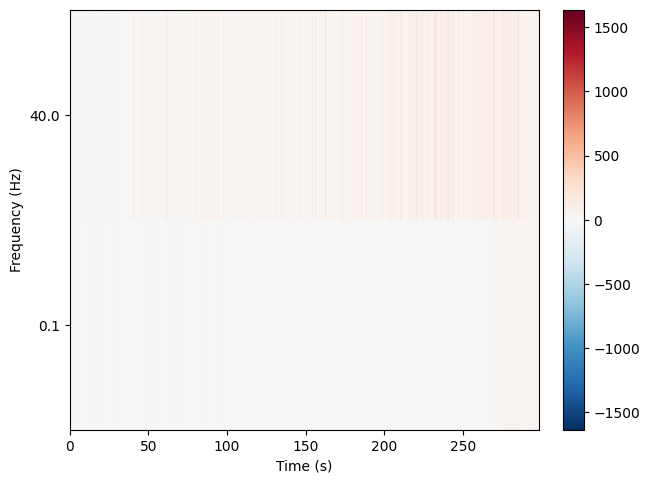

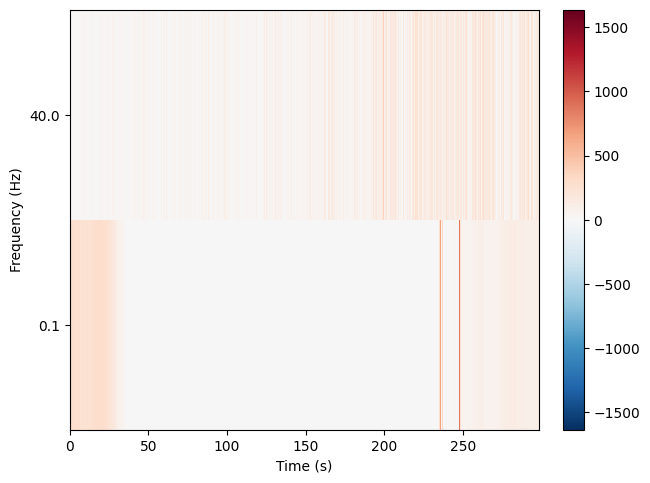

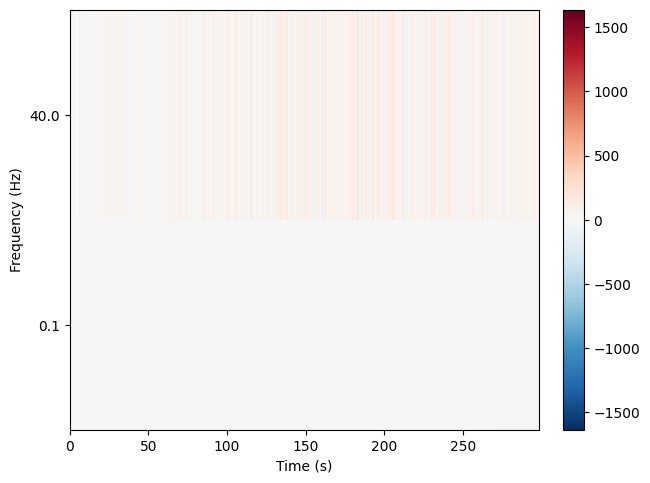

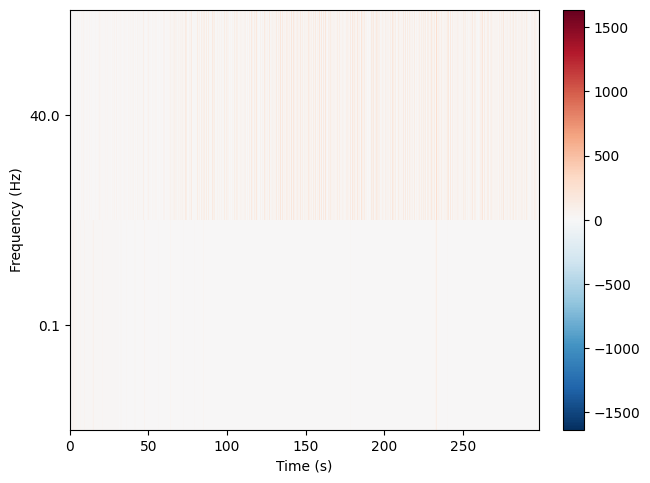

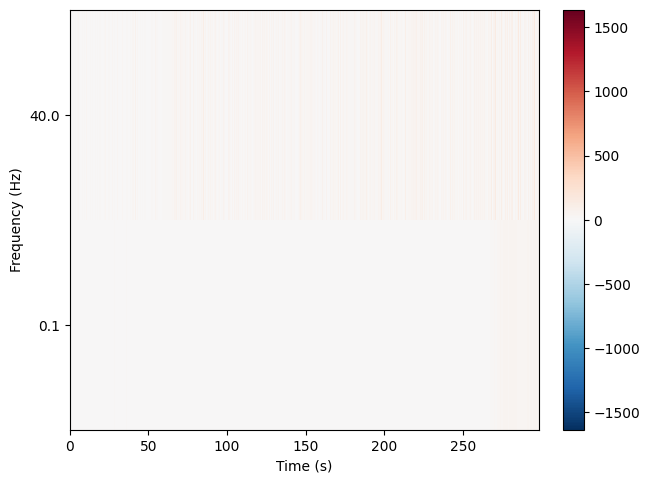

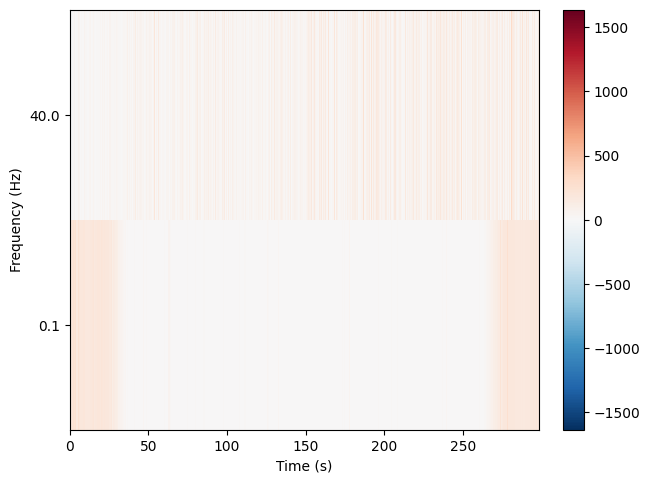

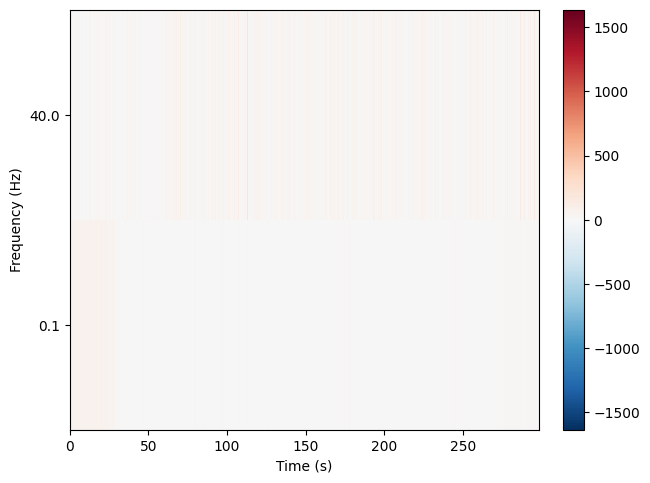

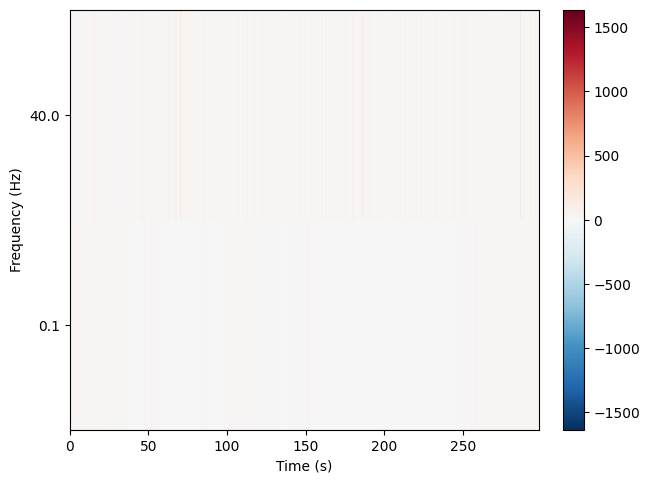

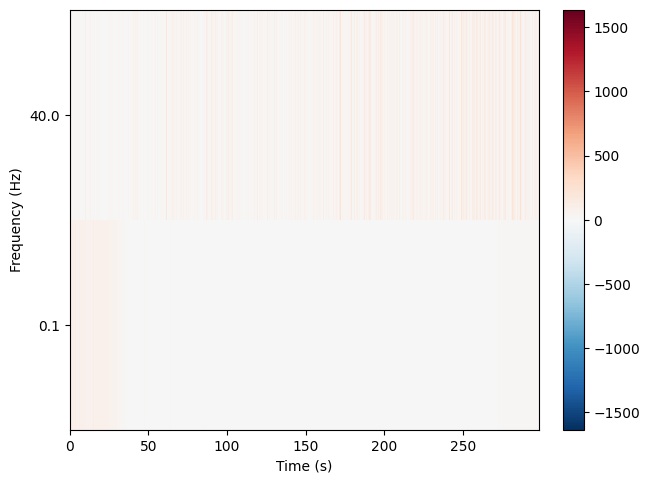

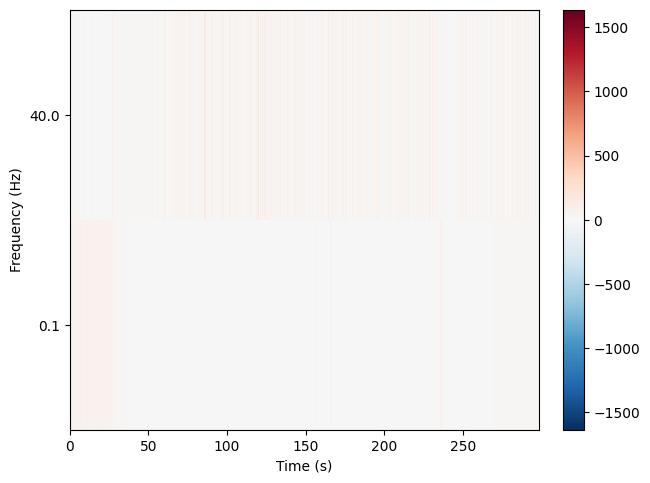

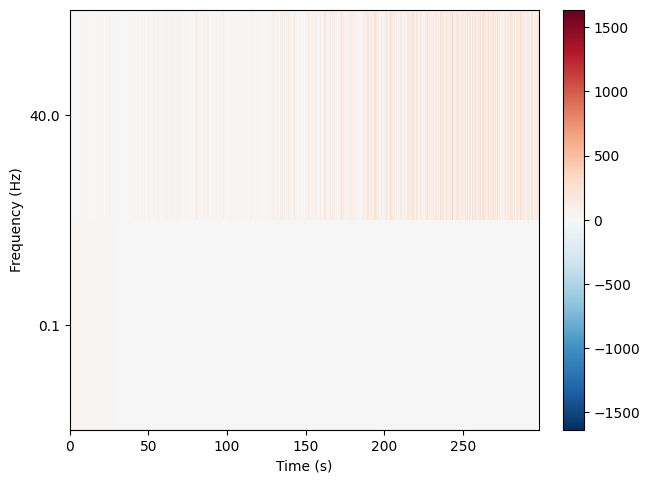

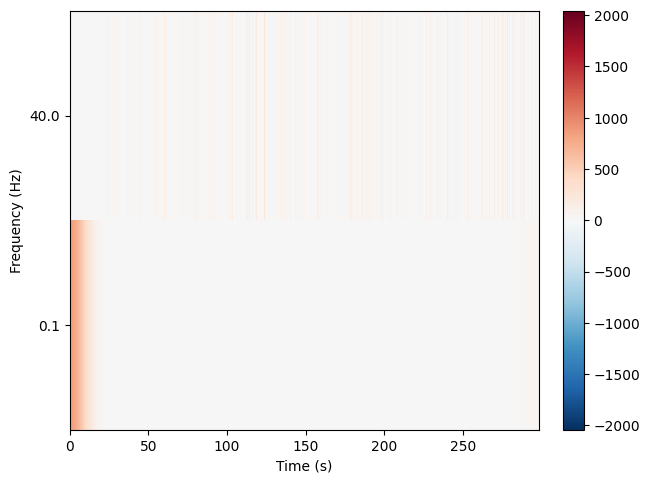

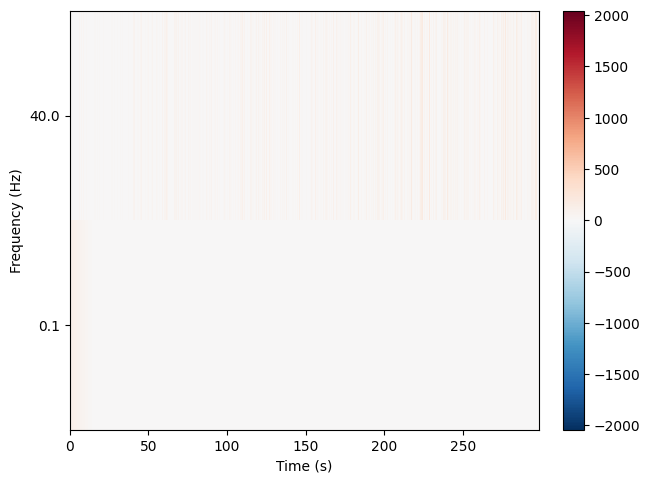

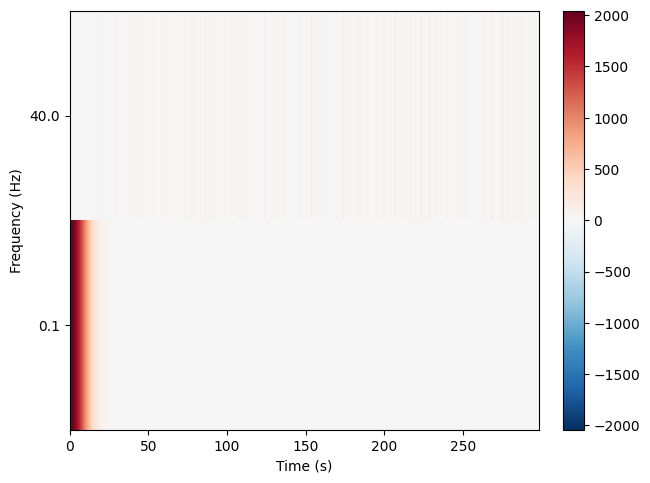

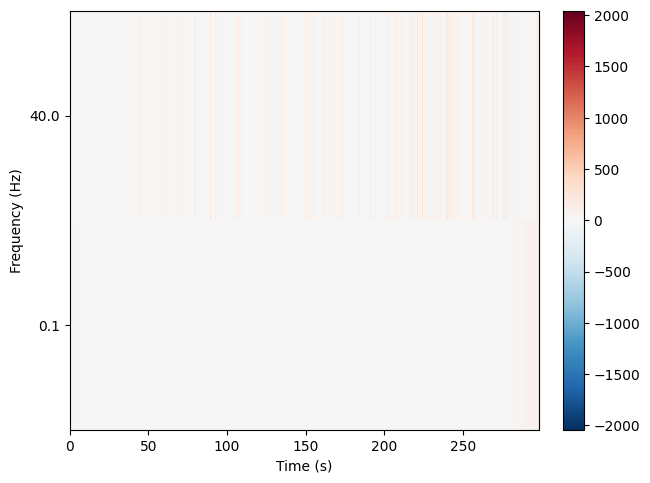

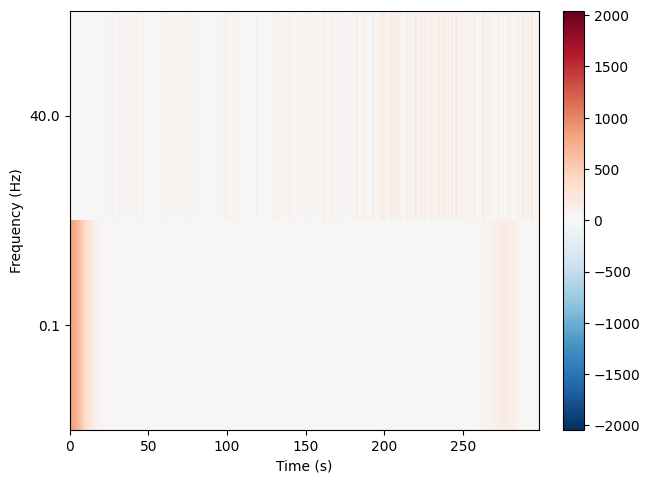

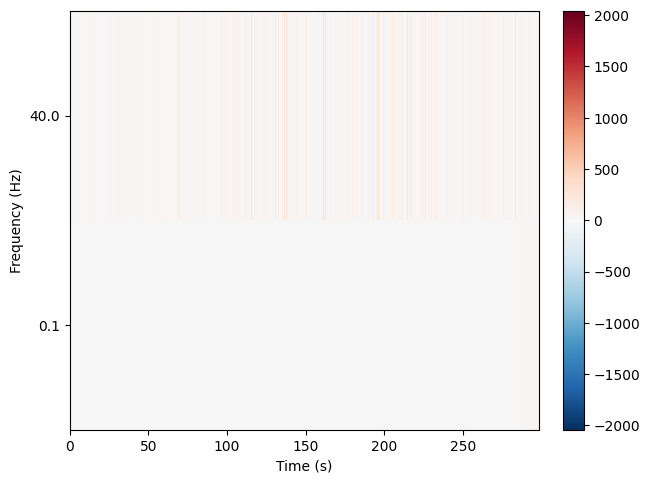

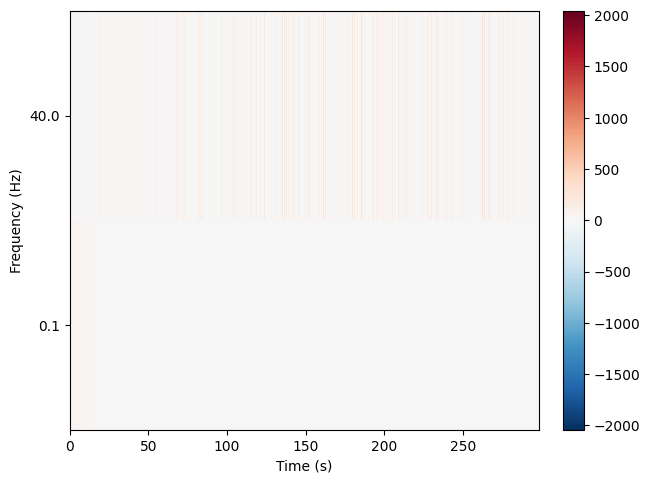

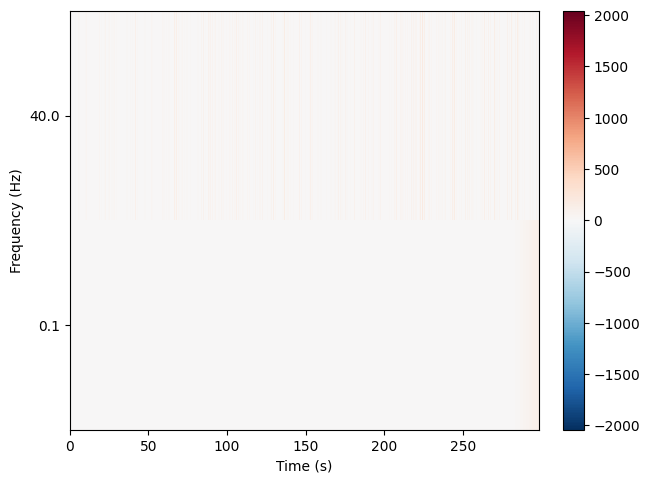

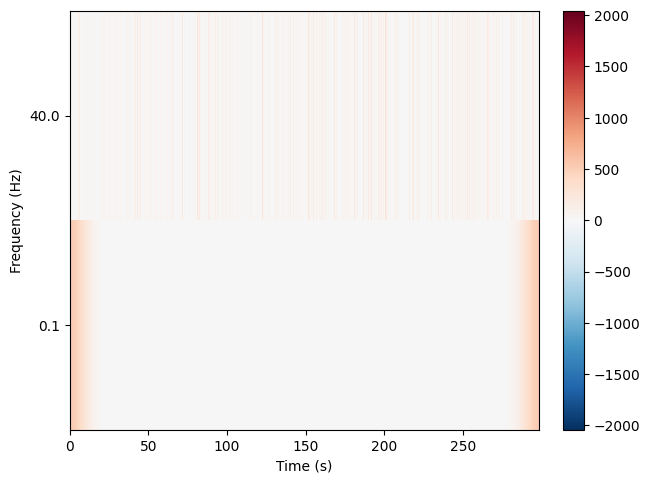

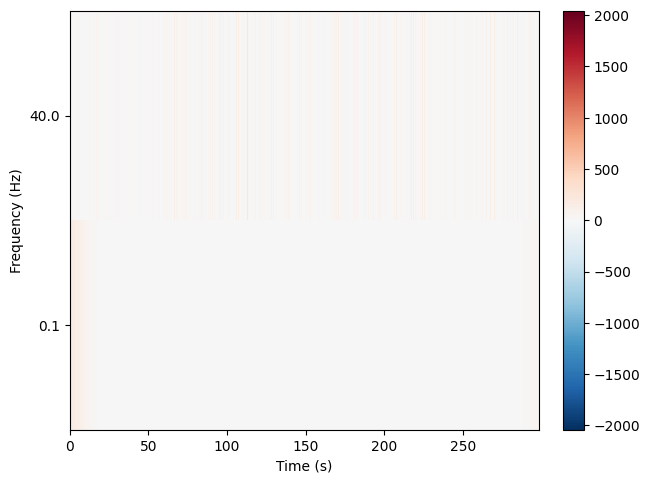

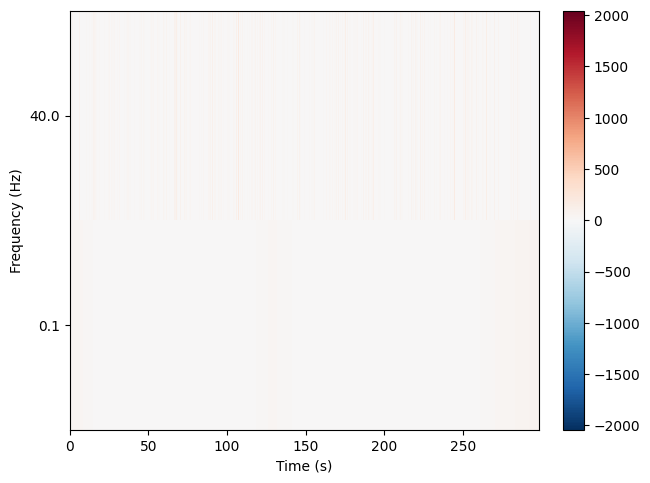

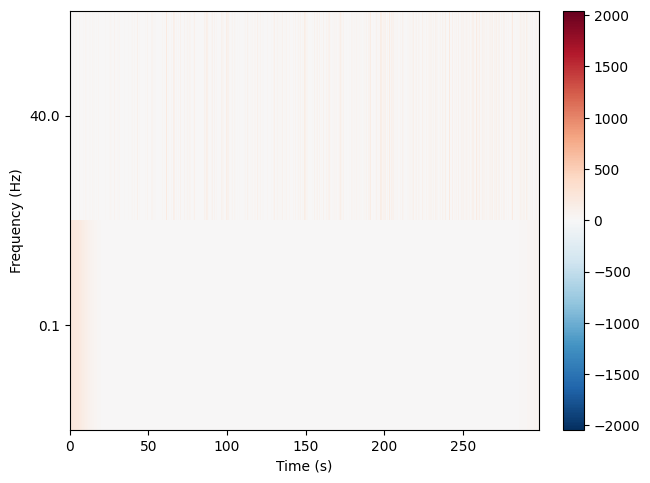

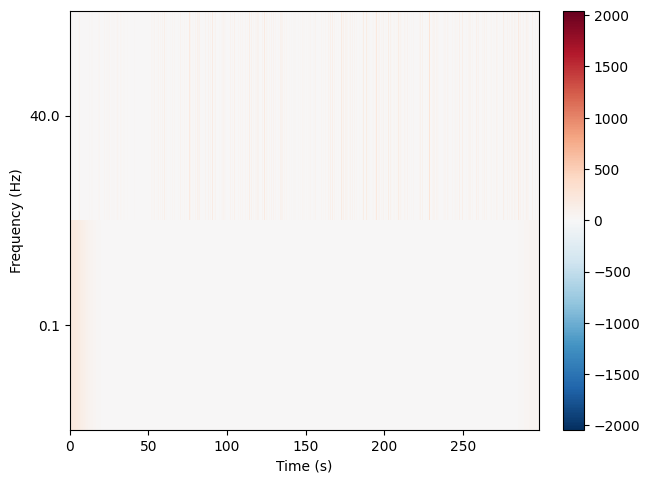

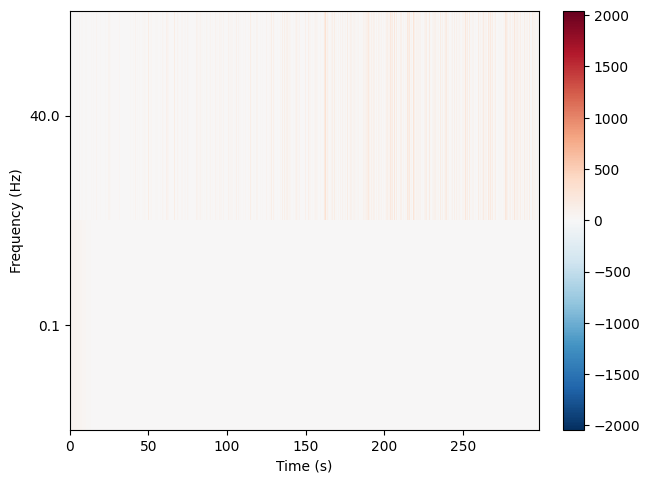

[<Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>,
 <Figure size 640x480 with 2 Axes>]

In [15]:
ica_psd.plot()
ica_tfr_multitaper.plot()
ica_tfr_morlet.plot()

In [16]:
# plot_all_subject_data(
#     pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G1AllChannels.csv'),
#     pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G2AllChannels.csv'),
#     pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G3AllChannels.csv'),
#     pd.read_csv(r'/kaggle/input/database-for-emotion-recognition-system-gameemo/GAMEEMO/(S03)/Preprocessed EEG Data/.csv format/S03G4AllChannels.csv'),
#     duration=2
# )